In [51]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron         # used for simple linear classfication task
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from tensorflow.keras.models import Sequential      # Sequential lets you build a neural network layer by layer in keras
from tensorflow.keras.layers import Dense           # dense maks the final prediction
from tensorflow.keras.layers import Conv2D          # convo2d extracts final prediction
from tensorflow.keras.layers import Flatten         # flatten reshapes them
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout         #dropout prevents overfitting
from tensorflow.keras.utils import to_categorical   # convert numeric clss label into on hot encoded vectors

In [52]:
df = pd.read_csv('fashion-mnist_train.csv')
df_test = pd.read_csv('fashion-mnist_test.csv')

In [53]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
df_test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [55]:
df.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


In [57]:
df.isnull().sum()

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64

In [58]:
X_train = df.drop('label',axis=1).values
y_train = df['label'].values
X_test = df.drop('label',axis=1).values
y_test = df['label'].values

### we are Going to convert every value between 0 and 1

In [59]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [60]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

If you have a column where values are like 0,1,2,3,4,5 by doing "One_hot_encoding" every values will will be in separate columns

In [61]:
y_test_cat = to_categorical(y_test,10)
y_train_cat = to_categorical(y_train,10)

## Creating Perceptron Model

In [62]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),    # converting image matris into an array
    Dense(10,activation="softmax")   # softmax is best when you are predicting multiple values
])

In [63]:
perceptron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [64]:
history_percep = perceptron.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7411 - loss: 0.8220 - val_accuracy: 0.7965 - val_loss: 0.6320
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8074 - loss: 0.5911 - val_accuracy: 0.8163 - val_loss: 0.5602
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8207 - loss: 0.5438 - val_accuracy: 0.8241 - val_loss: 0.5269
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8268 - loss: 0.5182 - val_accuracy: 0.8313 - val_loss: 0.5063
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8323 - loss: 0.5013 - val_accuracy: 0.8356 - val_loss: 0.4910


In [65]:
acc_percep = perceptron.evaluate(X_test_img,y_test_cat,verbose=1)[1]

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8356 - loss: 0.4910


In [66]:
acc_percep

0.8356166481971741

### ANN

In [67]:
ANN = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64 , activation='relu'),
    Dense(10, activation='softmax')
])

In [68]:
ANN.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

#### batch_size mean selecting number of rows

In [69]:
history_ANN = ANN.fit(X_train_img , y_train_cat , epochs=5 , batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8244 - loss: 0.4979 - val_accuracy: 0.8612 - val_loss: 0.3887
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8636 - loss: 0.3730 - val_accuracy: 0.8802 - val_loss: 0.3283
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8749 - loss: 0.3388 - val_accuracy: 0.8881 - val_loss: 0.3046
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8825 - loss: 0.3163 - val_accuracy: 0.8966 - val_loss: 0.2840
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8909 - loss: 0.2953 - val_accuracy: 0.9006 - val_loss: 0.2715


In [70]:
acc_ANN = ANN.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [71]:
acc_ANN

0.9006166458129883

### CNN

In [81]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

### kernel_size is telling about filter size in convolutional layer

### here FLATTEN is used because to make all feature in 1-D

In [73]:
CNN = Sequential([
    Conv2D(32, kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),   # first hidden layer
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [74]:
CNN.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [75]:
history_CNN = CNN.fit(X_train_cnn,y_train_cat,epochs=5,batch_size=32,validation_data=(X_text_cnn,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8014 - loss: 0.5511 - val_accuracy: 0.8690 - val_loss: 0.3476
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8667 - loss: 0.3717 - val_accuracy: 0.8983 - val_loss: 0.2777
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8845 - loss: 0.3185 - val_accuracy: 0.9040 - val_loss: 0.2567
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8942 - loss: 0.2922 - val_accuracy: 0.9175 - val_loss: 0.2194
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9023 - loss: 0.2680 - val_accuracy: 0.9227 - val_loss: 0.2056


In [82]:
acc_cnn = CNN.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]

In [83]:
acc_cnn

0.9226833581924438

In [84]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

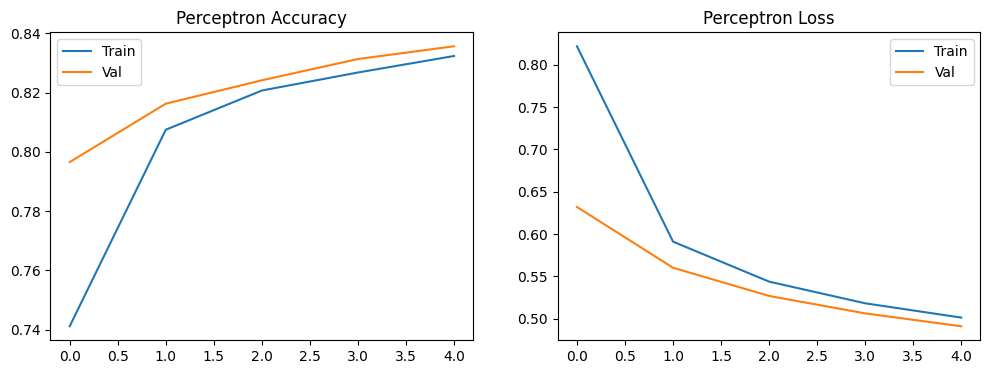

In [85]:
plot_training(history_percep, "Perceptron")

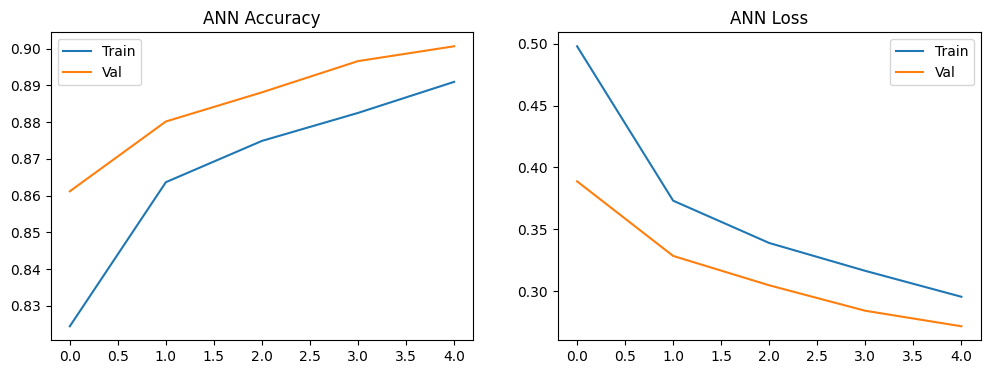

In [86]:
plot_training(history_ANN, "ANN")

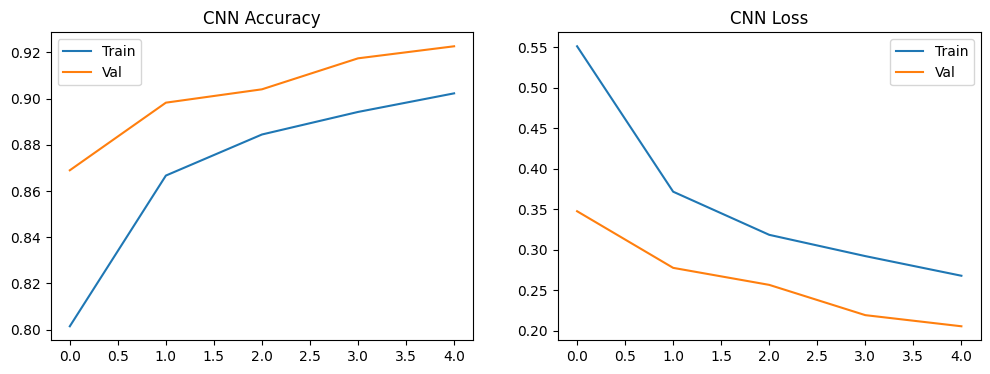

In [88]:
plot_training(history_CNN, "CNN")